# EDA: транзакции, заказы, товары (Olist)

Первичный анализ табличной части датасета: пропуски, распределения, корреляции числовых признаков.

Данные: `../data/raw/` (локальные копии CSV с Kaggle).

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
DATA = "../data/raw/"

In [16]:
orders = pd.read_csv(f"{DATA}olist_orders_dataset.csv")
items = pd.read_csv(f"{DATA}olist_order_items_dataset.csv")
products = pd.read_csv(f"{DATA}olist_products_dataset.csv")
customers = pd.read_csv(f"{DATA}olist_customers_dataset.csv")
categories = pd.read_csv(f"{DATA}product_category_name_translation.csv")

print("orders", orders.shape)
print("items", items.shape)
print("products", products.shape)
print("customers", customers.shape)
print("categories", categories.shape)

orders (99441, 8)
items (112650, 7)
products (32951, 9)
customers (99441, 5)
categories (71, 2)


## Пропуски и типы

In [17]:
orders.isnull().sum().sort_values(ascending=False).head(10)

order_delivered_customer_date    2965
order_delivered_carrier_date     1783
order_approved_at                 160
order_id                            0
order_purchase_timestamp            0
order_status                        0
customer_id                         0
order_estimated_delivery_date       0
dtype: int64

In [18]:
items.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


## Join для анализа заказ -> позиции -> товар

In [19]:
df = items.merge(orders, on="order_id", how="left")
df = df.merge(products, on="product_id", how="left")
df = df.merge(categories, on="product_category_name", how="left")
df.shape

(112650, 23)

## Время доставки (дни)

Далее используется в предобработке.

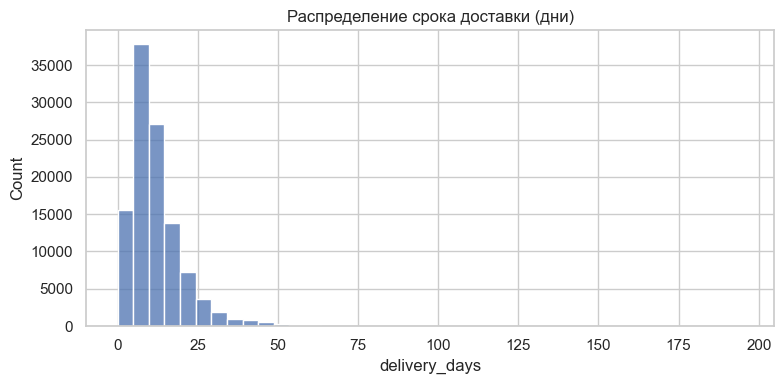

In [20]:
for c in ["order_purchase_timestamp", "order_delivered_customer_date"]:
    df[c] = pd.to_datetime(df[c], errors="coerce")

df["delivery_days"] = (df["order_delivered_customer_date"] - df["order_purchase_timestamp"]).dt.days
delivery = df["delivery_days"].dropna()
delivery = delivery[(delivery >= 0) & (delivery < 200)]

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(delivery, bins=40, ax=ax)
ax.set_title("Распределение срока доставки (дни)")
plt.tight_layout()
plt.show()

## Корреляция числовых признаков позиций заказа

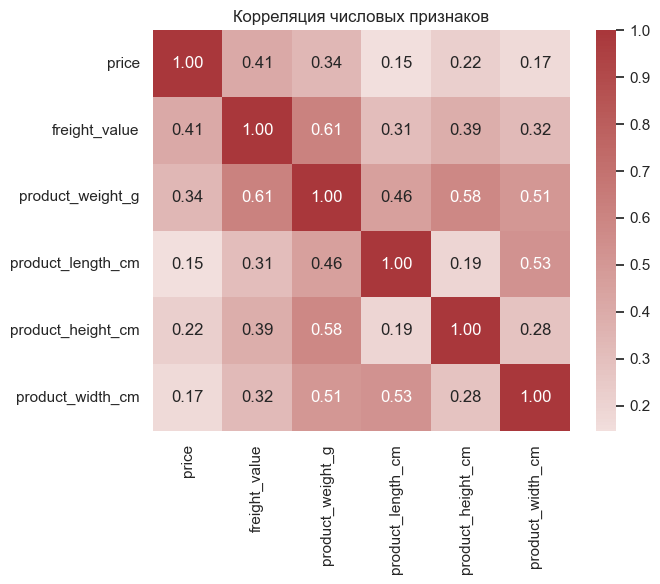

In [21]:
num_cols = ["price", "freight_value", "product_weight_g", "product_length_cm", "product_height_cm", "product_width_cm"]
num_cols = [c for c in num_cols if c in df.columns]
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, ax=ax)
ax.set_title("Корреляция числовых признаков")
plt.tight_layout()
plt.show()

## Статус заказа и регион клиента

Распределения, которые в пайплайне уходят в one-hot (`order_status_*`, `customer_state_*`).

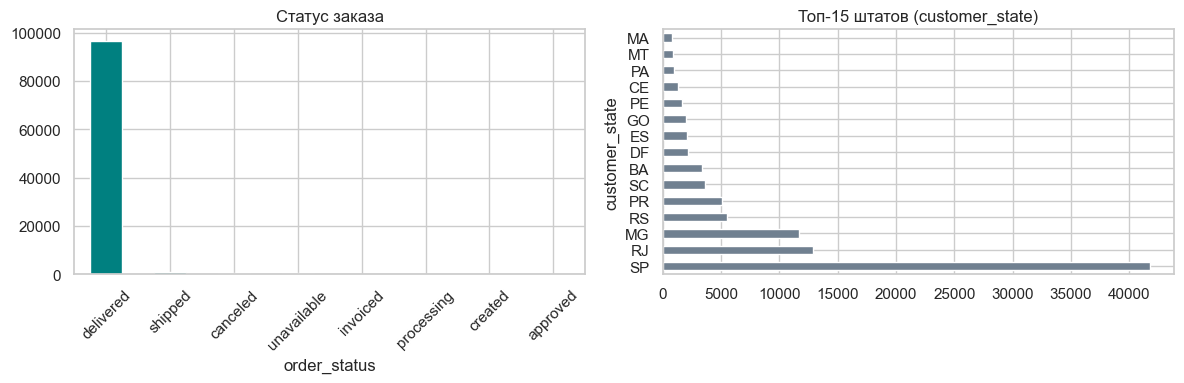

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

orders["order_status"].value_counts().plot(kind="bar", ax=axes[0], color="teal")
axes[0].set_title("Статус заказа")
axes[0].tick_params(axis="x", rotation=45)

customers["customer_state"].value_counts().head(15).plot(kind="barh", ax=axes[1], color="slategray")
axes[1].set_title("Топ-15 штатов (customer_state)")
plt.tight_layout()
plt.show()

## Способы оплаты

Дополнительная таблица `olist_order_payments_dataset.csv` (связь с заказом по `order_id`).

payments (103886, 5)
payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64


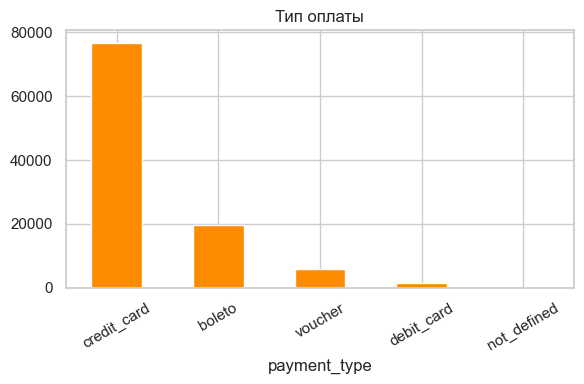

In [23]:
payments = pd.read_csv(f"{DATA}olist_order_payments_dataset.csv")
print("payments", payments.shape)
print(payments["payment_type"].value_counts())

fig, ax = plt.subplots(figsize=(6, 4))
payments["payment_type"].value_counts().plot(kind="bar", ax=ax, color="darkorange")
ax.set_title("Тип оплаты")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

## Постановка задачи ML

- **Задача**: по признакам заказа/доставки/товара и отзыву предсказать удовлетворённость (`is_satisfied`: оценка отзыва ≥ 4).
- **Метрики**: F1, ROC-AUC (классы могут быть несбалансированы).

## Признаки для `transactions_preprocess.py`

Ниже собираем данные на уровне заказа и смотрим, какие агрегаты и производные признаки действительно стоит перенести в пайплайн.

In [24]:
reviews_tx = pd.read_csv(
    f"{DATA}olist_order_reviews_dataset.csv",
    usecols=["order_id", "review_score"],
)
reviews_tx["is_satisfied"] = (reviews_tx["review_score"] >= 4).astype(int)

orders_tx = orders.copy()
date_cols = [
    "order_purchase_timestamp",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
]
for col in date_cols:
    orders_tx[col] = pd.to_datetime(orders_tx[col], errors="coerce")

items_agg = (
    items.groupby("order_id")
    .agg(
        items_count=("order_item_id", "max"),
        total_price=("price", "sum"),
        total_freight=("freight_value", "sum"),
        avg_item_price=("price", "mean"),
    )
    .reset_index()
)

order_level = (
    orders_tx.merge(customers[["customer_id", "customer_state"]], on="customer_id", how="left")
    .merge(items_agg, on="order_id", how="left")
    .merge(reviews_tx[["order_id", "is_satisfied"]], on="order_id", how="inner")
)
print("order_level:", order_level.shape)

order_level: (99224, 14)


In [25]:
order_level["delivery_days"] = (
    order_level["order_delivered_customer_date"] - order_level["order_purchase_timestamp"]
).dt.days
order_level["estimated_days"] = (
    order_level["order_estimated_delivery_date"] - order_level["order_purchase_timestamp"]
).dt.days
order_level["delivery_delay_days"] = order_level["delivery_days"] - order_level["estimated_days"]
order_level["is_late_delivery"] = (order_level["delivery_delay_days"] > 0).astype(int)
order_level["purchase_hour"] = order_level["order_purchase_timestamp"].dt.hour
order_level["purchase_dayofweek"] = order_level["order_purchase_timestamp"].dt.dayofweek
order_level["purchase_month"] = order_level["order_purchase_timestamp"].dt.month
order_level["freight_to_price_ratio"] = order_level["total_freight"] / order_level["total_price"].clip(lower=1)

In [26]:
summary = (
    order_level.groupby("is_satisfied")[[
        "delivery_days",
        "delivery_delay_days",
        "items_count",
        "total_price",
        "freight_to_price_ratio",
    ]]
    .median()
    .round(2)
)
print("Медианы order-level признаков по целевой переменной:")
display(summary)

late_rate = (
    order_level.groupby("is_late_delivery")["is_satisfied"]
    .mean()
    .rename("satisfaction_rate")
    .round(3)
)
print("Доля удовлетворённых клиентов при своевременной/поздней доставке:")
display(late_rate.to_frame())

state_share = (
    order_level.groupby("customer_state")["order_id"]
    .count()
    .sort_values(ascending=False)
    .head(10)
)
print("Топ-10 штатов по числу заказов:")
display(state_share.to_frame("orders"))

Медианы order-level признаков по целевой переменной:


,delivery_days,delivery_delay_days,items_count,total_price,freight_to_price_ratio
is_satisfied,,,,,
0,13.0,-9.0,1.0,89.99,0.23
1,9.0,-12.0,1.0,84.90,0.22


Доля удовлетворённых клиентов при своевременной/поздней доставке:


,satisfaction_rate
is_late_delivery,
0,0.806
1,0.318


Топ-10 штатов по числу заказов:


,orders
customer_state,
SP,41690
RJ,12765
MG,11625
RS,5483
PR,5038
SC,3623
BA,3357
DF,2148
GO,2024


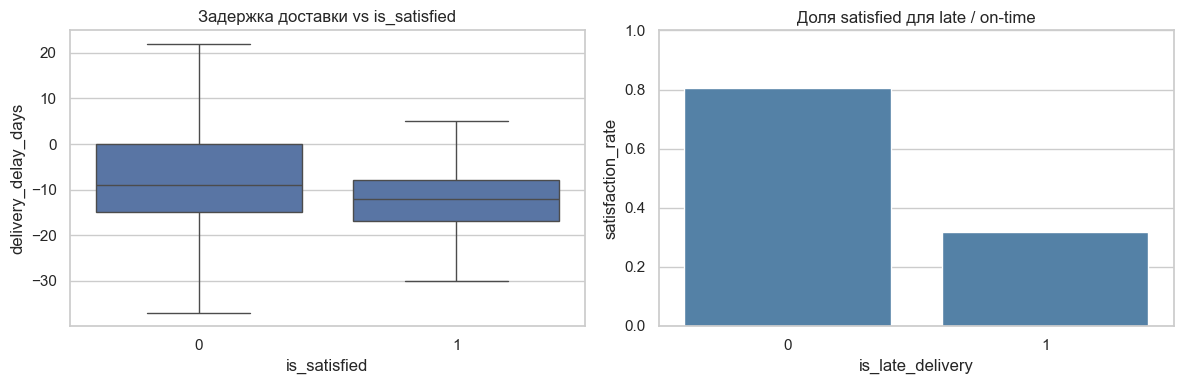

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(
    data=order_level.dropna(subset=["delivery_delay_days"]),
    x="is_satisfied",
    y="delivery_delay_days",
    showfliers=False,
    ax=axes[0],
)
axes[0].set_title("Задержка доставки vs is_satisfied")
axes[0].set_xlabel("is_satisfied")
axes[0].set_ylabel("delivery_delay_days")

late_plot = late_rate.reset_index()
sns.barplot(data=late_plot, x="is_late_delivery", y="satisfaction_rate", ax=axes[1], color="steelblue")
axes[1].set_title("Доля satisfied для late / on-time")
axes[1].set_xlabel("is_late_delivery")
axes[1].set_ylabel("satisfaction_rate")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [28]:
candidate_features = pd.Series(
    {
        "delivery_delay_days": "оставить как основной признак качества доставки",
        "is_late_delivery": "добавить как бинарный флаг опоздания",
        "items_count": "агрегировать на уровне заказа",
        "total_price": "агрегировать на уровне заказа",
        "freight_to_price_ratio": "оставить как относительную стоимость доставки",
        "purchase_hour / dayofweek / month": "сохранить как календарные признаки",
        "customer_state": "оставить для OHE по низкой кардинальности на уровне штата",
    }
)
display(candidate_features.to_frame("Почему полезно"))

,Почему полезно
delivery_delay_days,оставить как основной признак качества доставки
is_late_delivery,добавить как бинарный флаг опоздания
items_count,агрегировать на уровне заказа
total_price,агрегировать на уровне заказа
freight_to_price_ratio,оставить как относительную стоимость доставки
purchase_hour / dayofweek / month,сохранить как календарные признаки
customer_state,оставить для OHE по низкой кардинальности на у...


### Вывод для пайплайна

По order-level EDA видно, что в `transactions_preprocess.py` логично расширять не только базовые числовые признаки, но и агрегаты на уровне заказа. В первую очередь стоит сохранить или добавить `delivery_delay_days`, `is_late_delivery`, `items_count`, `total_price`, `freight_to_price_ratio` и календарные признаки покупки. Это хорошо согласуется с текущей логикой `join_features.py`, где данные всё равно агрегируются до `order_id`.